In [1]:
!pip install IPython

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [3]:
# --------------------------------------------
# 2. Load and Inspect Data
# --------------------------------------------
DATA_PATH = "dashboard_design.csv" 
df = pd.read_csv(DATA_PATH)

# Convert date columns to datetime
df['event_date'] = pd.to_datetime(df['event_date'])

if 'first_event_date' in df.columns:
    df['first_event_date'] = pd.to_datetime(df['first_event_date'], errors='coerce')

print(f"Total rows in raw CSV: {len(df)}")
print("Columns in raw DataFrame:", df.columns.tolist())
print("\nSample of the raw data:")
display(df.head())

C:\Users\kemal\AppData\Local\Temp\ipykernel_12516\940427997.py:5: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


Total rows in raw CSV: 756690
Columns in raw DataFrame: ['user_id', 'event_time', 'event_date', 'event_name', 'first_event_date', 'operating_system', 'country', 'source', 'revenue', 'product_identifier']

Sample of the raw data:


,user_id,event_time,event_date,event_name,first_event_date,operating_system,country,source,revenue,product_identifier
0,ca715a5ae4e4b4,1687382160145,2023-06-21,app_launch,2023-06-21,android,ES,NaN,NaN,NaN
1,25792D2DFEFE-C,1687398652382,2023-06-22,app_launch,2023-06-22,ios,US,NaN,NaN,NaN
2,4D8937375B5B-3,1687400507996,2023-06-22,app_launch,2023-06-22,ios,US,NaN,NaN,NaN
3,43697A7A0B0B-9,1687374756360,2023-06-21,app_launch,2023-06-13,ios,SG,NaN,NaN,NaN
4,c354e1e19c9c39,1687377345784,2023-06-21,app_launch,2023-06-21,android,US,NaN,NaN,NaN


In [19]:
product_id_counts = (
    df['source']
      .value_counts(dropna=False)
      .reset_index()
)
product_id_counts

,source,count
0,NaN,347585
1,blue,142886
2,red,129876
3,lime,73236
4,pink,40709
5,orange,13719
6,yellow,4464
7,purple,4173
8,green,42


In [7]:
# --------------------------------------------
# 3. Compute Daily Metrics
# --------------------------------------------

# 3.1 Daily Active Users (DAU): unique user_id count per event_date
daily_active = (
    df.groupby('event_date')['user_id']
      .nunique()
      .rename('daily_active_users')
)

# 3.2 Daily New Users: user_id is “new” if event_date == first_event_date
if 'first_event_date' in df.columns:
    new_users = (
        df[df['event_date'] == df['first_event_date']]
          .groupby('event_date')['user_id']
          .nunique()
          .rename('daily_new_users')
    )
else:
    # If there is no first_event_date in your CSV, create an empty series
    new_users = pd.Series(dtype='int64', name='daily_new_users')

# 3.3 Daily Revenue: sum of revenue per day
# Make sure there is a 'revenue' column; if not, create zeros.
if 'revenue' not in df.columns:
    df['revenue'] = 0

df['revenue'] = df['revenue'].fillna(0)
daily_revenue = (
    df.groupby('event_date')['revenue']
      .sum()
      .rename('daily_revenue')
)

# 3.4 Daily Event Counts: one column per event_name, counting rows per day
daily_event_counts = (
    df.groupby(['event_date', 'event_name'])['user_id']
      .count()
      .unstack(fill_value=0)
)

# 3.5 Combine all daily metrics into one DataFrame
daily_metrics = pd.concat(
    [daily_active, new_users, daily_revenue, daily_event_counts],
    axis=1
).fillna(0).reset_index().sort_values('event_date')

# For readability, cast any float columns that should be int back to int
daily_metrics['daily_active_users'] = daily_metrics['daily_active_users'].astype(int)
daily_metrics['daily_new_users']   = daily_metrics['daily_new_users'].astype(int)
daily_metrics['daily_revenue']     = daily_metrics['daily_revenue'].astype(float)
for col in daily_event_counts.columns:
    daily_metrics[col] = daily_metrics[col].astype(int)

# Display the consolidated daily_metrics DataFrame
print("\n=== Consolidated Daily Metrics ===")
display(daily_metrics)


=== Consolidated Daily Metrics ===


,event_date,daily_active_users,daily_new_users,daily_revenue,app_launch,auto_renew_off,free_trial,paywall,refund,renewal,subscribe
0,2023-06-18,1824,1177,492.590,2320,110,159,3062,1,17,49
1,2023-06-19,1811,1115,584.066,2342,115,140,2857,2,22,44
2,2023-06-20,1404,830,425.292,1773,88,82,2252,1,18,31
3,2023-06-21,1419,887,292.712,1816,94,103,2360,0,18,24
4,2023-06-22,1225,709,394.730,1479,82,77,1809,0,26,29
...,...,...,...,...,...,...,...,...,...,...,...
116,2023-10-12,1587,835,519.610,2068,109,77,2847,1,34,38
117,2023-10-13,2091,1206,803.432,2797,143,154,3921,0,51,43
118,2023-10-14,2497,1538,980.910,3336,181,189,4817,1,46,50
119,2023-10-15,2241,1305,970.886,2950,170,158,4303,0,53,44


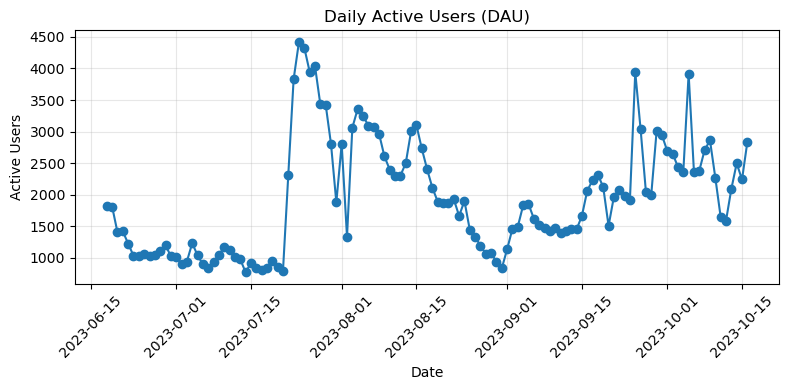

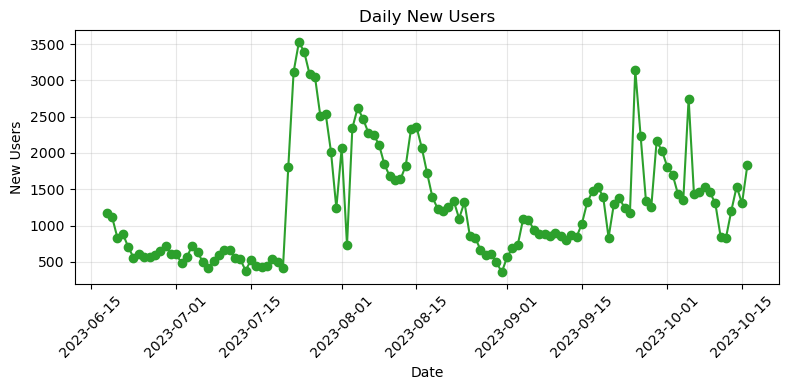

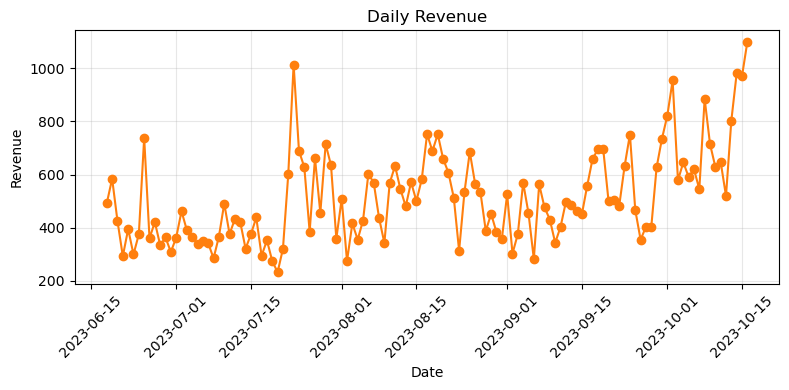

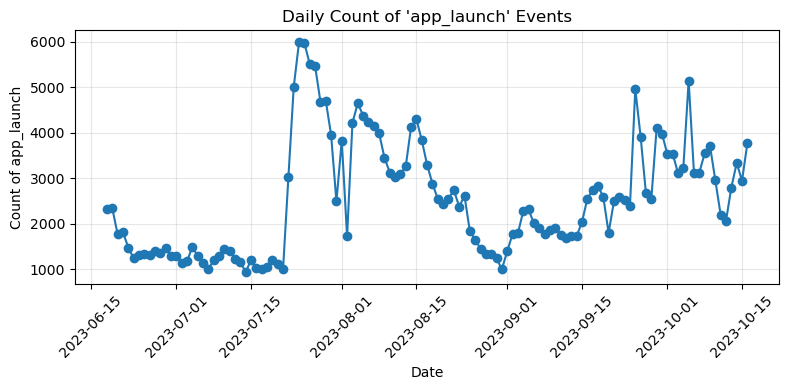

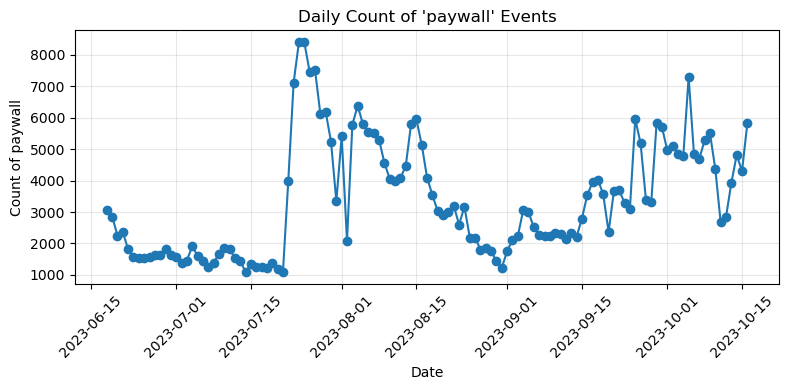

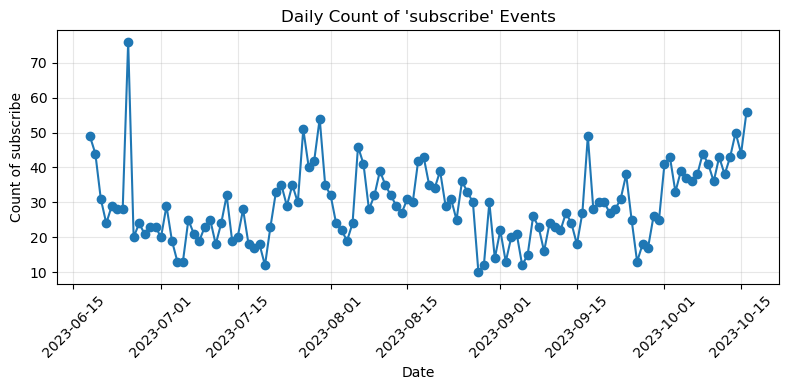

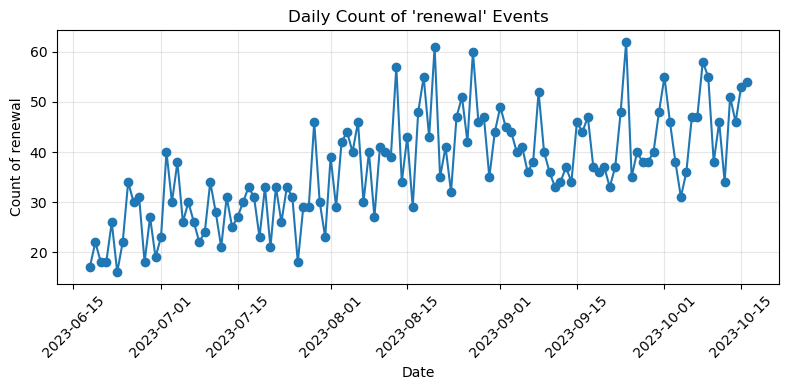

In [9]:
# --------------------------------------------
# 4. Plotting the Core Time Series
# --------------------------------------------
plt.rcParams['figure.figsize'] = (8, 4)  # set a default figure size

# 4.1 Daily Active Users (DAU) over Time
plt.figure()
plt.plot(daily_metrics['event_date'], daily_metrics['daily_active_users'], marker='o')
plt.title("Daily Active Users (DAU)")
plt.xlabel("Date")
plt.ylabel("Active Users")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4.2 Daily New Users over Time  
if 'daily_new_users' in daily_metrics.columns:
    plt.figure()
    plt.plot(daily_metrics['event_date'], daily_metrics['daily_new_users'], marker='o', color='tab:green')
    plt.title("Daily New Users")
    plt.xlabel("Date")
    plt.ylabel("New Users")
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# 4.3 Daily Revenue over Time
plt.figure()
plt.plot(daily_metrics['event_date'], daily_metrics['daily_revenue'], marker='o', color='tab:orange')
plt.title("Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4.4 Daily Event Counts for Key Events 
key_events = ['app_launch', 'paywall', 'subscribe', 'renewal']
for event in key_events:
    if event in daily_metrics.columns:
        plt.figure()
        plt.plot(daily_metrics['event_date'], daily_metrics[event], marker='o')
        plt.title(f"Daily Count of '{event}' Events")
        plt.xlabel("Date")
        plt.ylabel(f"Count of {event}")
        plt.xticks(rotation=45)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()



=== Unique Users by Operating System ===


,os_norm,unique_users
0,android,117065
1,ios,53763
2,unknown,29
3,ipados,13


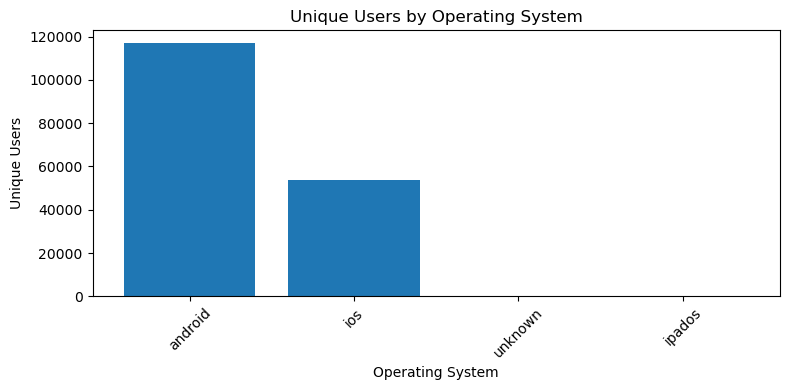


=== Top 10 Countries by Unique Users ===


,country,unique_users
0,US,69791
1,ZA,25509
2,PH,20283
3,GB,6781
4,DE,4212
5,CA,3525
6,MX,3060
7,AU,2794
8,BR,2447
9,FR,1720


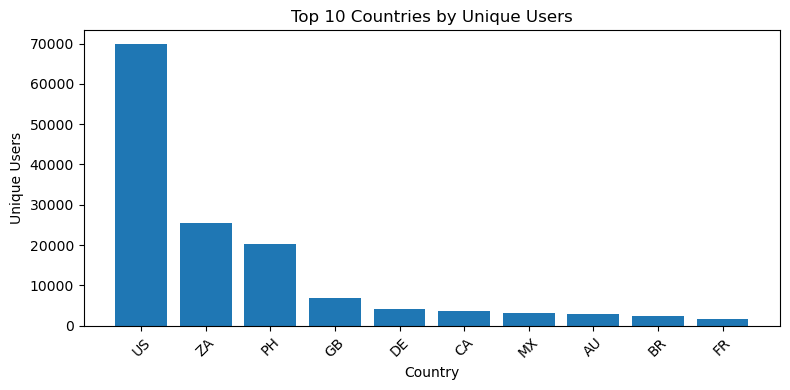

In [11]:
# --------------------------------------------
# 5. User Segmentation Charts
# --------------------------------------------

# 5.1 Unique Users by Operating System
# Normalize OS (lowercase) and count distinct users
df['os_norm'] = df['operating_system'].str.lower().fillna("unknown")
unique_users_os = (
    df.groupby('os_norm')['user_id']
      .nunique()
      .rename('unique_users')
      .sort_values(ascending=False)
      .reset_index()
)

print("\n=== Unique Users by Operating System ===")
display(unique_users_os)

plt.figure()
plt.bar(unique_users_os['os_norm'], unique_users_os['unique_users'])
plt.title("Unique Users by Operating System")
plt.xlabel("Operating System")
plt.ylabel("Unique Users")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5.2 Top 10 Countries by Unique Users (if 'country' exists)
if 'country' in df.columns:
    unique_users_country = (
        df[df['country'].notna()]
          .groupby('country')['user_id']
          .nunique()
          .rename('unique_users')
          .sort_values(ascending=False)
          .head(10)
          .reset_index()
    )

    print("\n=== Top 10 Countries by Unique Users ===")
    display(unique_users_country)

    plt.figure()
    plt.bar(unique_users_country['country'], unique_users_country['unique_users'])
    plt.title("Top 10 Countries by Unique Users")
    plt.xlabel("Country")
    plt.ylabel("Unique Users")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [13]:
# --------------------------------------------
# 6. Export Processed Daily Metrics to CSV
# --------------------------------------------
OUTPUT_PATH = "daily_metrics_dashboard.csv"
daily_metrics.to_csv(OUTPUT_PATH, index=False)
print(f"\nDaily metrics exported to: {OUTPUT_PATH}")


Daily metrics exported to: daily_metrics_dashboard.csv
